In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

sns.set_theme(style='whitegrid')

# Diabetes Prediction Using Logistic Regression
## 1. Project Introduction
This project analyzes the Pima Indians Diabetes dataset and uses Logistic Regression to predict whether a person has diabetes.

In [37]:
# Choose the dataset
from google.colab import files
uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)
print('Shape:', df.shape)
df.head()

Saving diabetes.csv to diabetes (1).csv
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [39]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [40]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 9


In [41]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [42]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Data Cleaning
Some medical measurements contain zero values that are not meaningful measurements. These values are treated as missing values and handled using median imputation.

In [43]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [44]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [45]:
df_before_duplicates = df.shape[0]
df = df.drop_duplicates().copy()
df_after_duplicates = df.shape[0]

print("Rows before removing duplicates:", df_before_duplicates)
print("Rows after removing duplicates:", df_after_duplicates)
print("Duplicates removed:", df_before_duplicates - df_after_duplicates)

Rows before removing duplicates: 768
Rows after removing duplicates: 768
Duplicates removed: 0


In [46]:
df.shape

(768, 9)

In [47]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


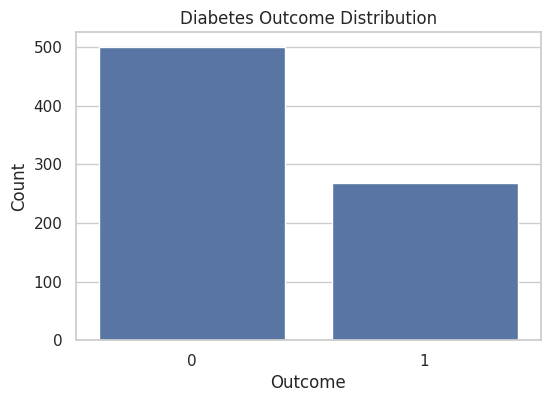

In [48]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

In [49]:
zero_columns = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
for column in zero_columns:
    print(column, ":", (df[column] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [50]:
df[zero_columns] = df[zero_columns].replace(0, np.nan)
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [51]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [52]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
df[zero_columns] = imputer.fit_transform(df[zero_columns])
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [53]:
print("Missing values after imputation:")
print(df.isnull().sum())
print("\nDataset shape:")
print(df.shape)

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Dataset shape:
(768, 9)


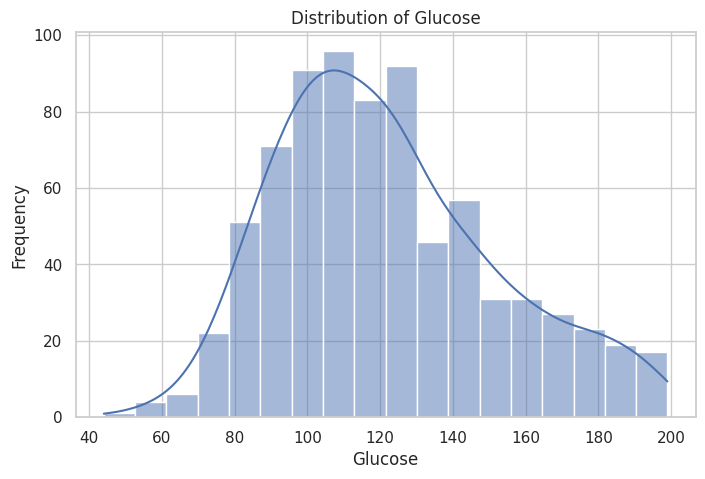

In [54]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Glucose"], kde=True)
plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

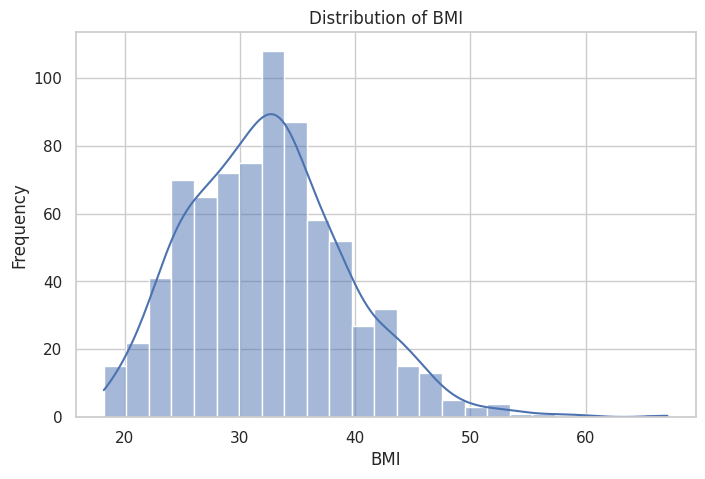

In [55]:
plt.figure(figsize=(8, 5))
sns.histplot(df["BMI"], kde=True)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

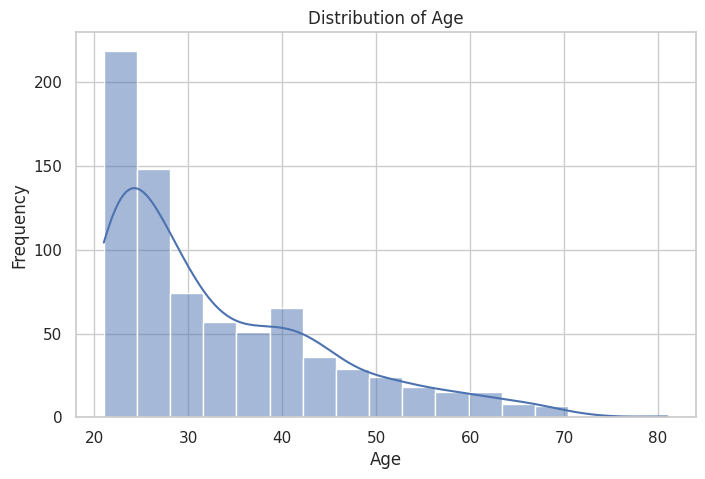

In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

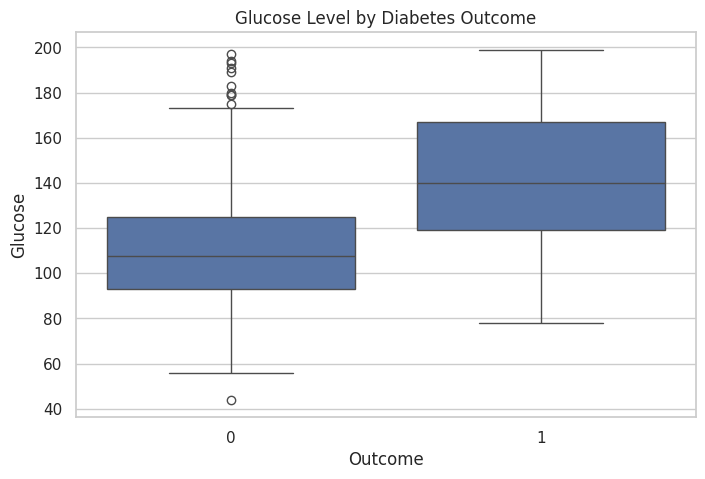

In [57]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.title("Glucose Level by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")
plt.show()

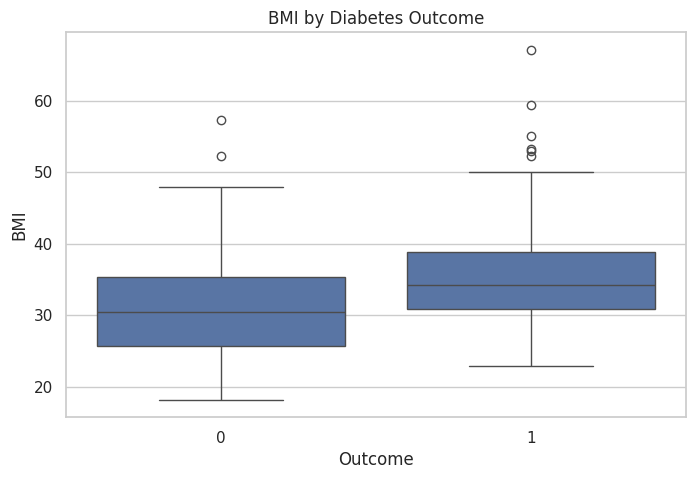

In [58]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.title("BMI by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")
plt.show()

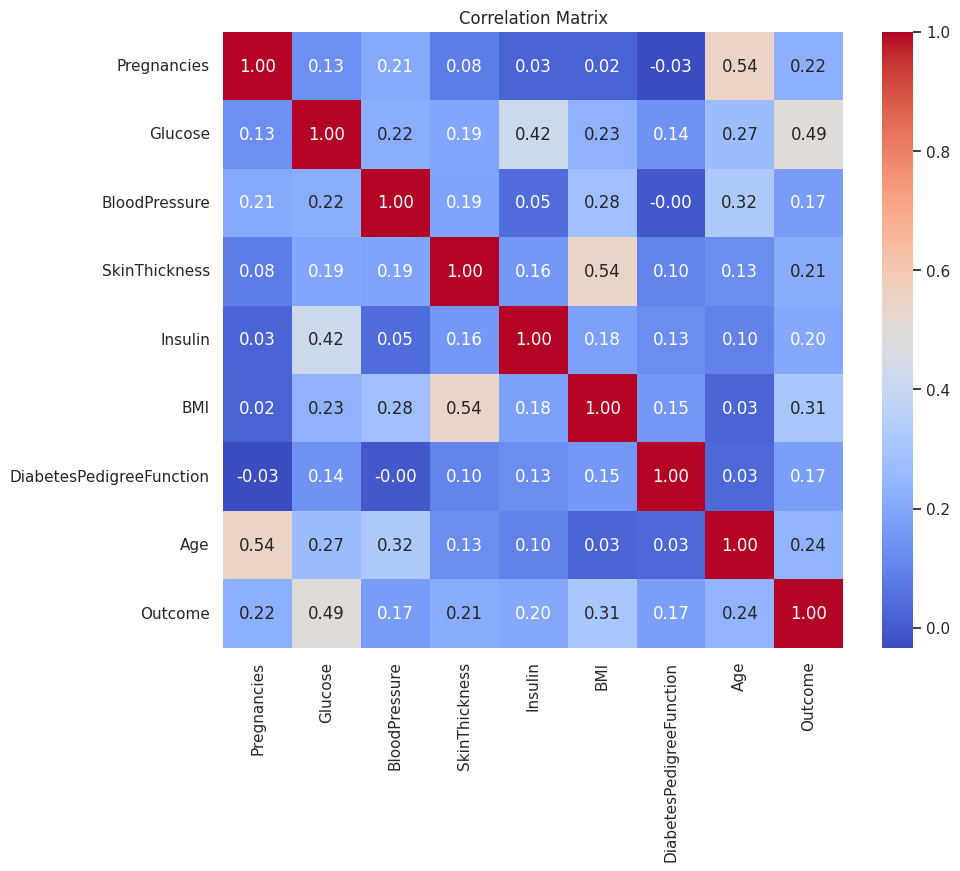

In [59]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

### Observation
The BMI distribution is concentrated mainly between 25 and 40, with a few higher BMI values. The distribution is slightly right-skewed.

In [60]:
# Separate input features and target variable
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


## 3. Train-Test Split
The cleaned dataset is divided into training and testing sets. 80% of the data is used for training and 20% is used for testing.

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [62]:
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train),columns=X_train.columns,index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test),columns=X_test.columns,index=X_test.index)

print("Missing values in training data:")
print(X_train.isnull().sum())
print("\nMissing values in testing data:")
print(X_test.isnull().sum())

Missing values in training data:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Missing values in testing data:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [63]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed.")

Feature scaling completed.


## 4. Logistic Regression Model
Logistic Regression is used to predict whether a person has diabetes or not. Class balancing is applied to handle the difference between
the two outcome classes.

In [64]:
model = LogisticRegression(class_weight="balanced",random_state=42,max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [65]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
print("Predictions completed.")

Predictions completed.


## 5. Model Evaluation
The model is evaluated using Accuracy, Precision, Recall and F1 Score.

In [66]:
# Metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)
conf_matrix = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7337662337662337
Precision: 0.6031746031746031
Recall: 0.7037037037037037
F1 Score: 0.6495726495726496


In [67]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8125925925925926


In [71]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



## 6. Confusion Matrix

The confusion matrix shows the correctly and incorrectly classified
diabetic and non-diabetic cases.

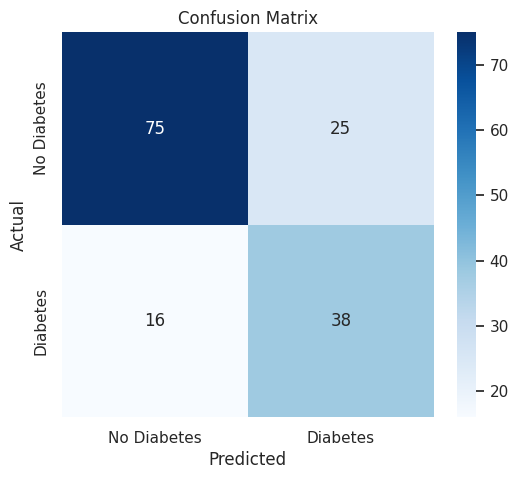

In [72]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No Diabetes", "Diabetes"],yticklabels=["No Diabetes", "Diabetes"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 7. ROC Curve
The ROC curve is used to evaluate the model's ability to distinguish between the two outcome classes.

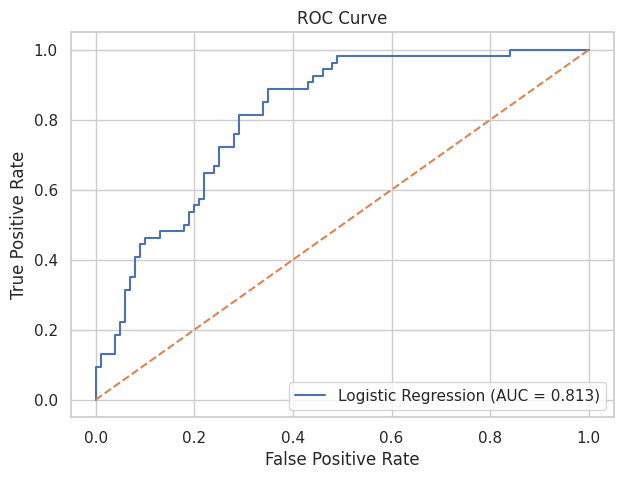

In [73]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 8. Feature Coefficients
The Logistic Regression coefficients show the direction and relative contribution of each feature to the prediction.

In [74]:
coefficients = pd.DataFrame({"Feature": X.columns,"Coefficient": model.coef_[0]})
coefficients = coefficients.sort_values(by="Coefficient",ascending=False)
print(coefficients)

                    Feature  Coefficient
1                   Glucose     1.183444
5                       BMI     0.709709
0               Pregnancies     0.373019
6  DiabetesPedigreeFunction     0.287745
7                       Age     0.186393
3             SkinThickness     0.013877
2             BloodPressure    -0.014548
4                   Insulin    -0.044651
